In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch
from sklearn.metrics.pairwise import pairwise_distances

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
def moons():
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)
    return data.to(device), labels.to(device)

def circles():
    X, y = make_circles(n_samples=1000, noise=0.05, factor=0.65)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)
    return data.to(device), labels.to(device)

def streched_gaussians():
    X, Labels = make_blobs(n_samples=1000, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)

    data = (X_aniso - X_aniso.mean(axis=0)) / X_aniso.std(axis=0)
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(Labels, dtype=torch.float32)
    return data.to(device), labels.to(device)

def combined_structure():
    data, labels = make_moons(n_samples=500, noise=0.1)

    # take the upper moons as data1
    data1 = data[labels == 0]
    data1[:, 0] = data1[:, 0] * 2

    # lower moon as data2
    data2 = data[labels == 1]

    # move and scale lower moon
    data2 = (data2 + np.array([-1, 1.5])) * -3

    # gaussian distribution at 0 0
    data3 = np.random.normal(loc=np.array([0, -1]), scale=0.65, size=(500, 2))

    labels = np.zeros(1000, dtype=int)
    labels[250:] = 1
    labels[500:] = 2
    
    data = np.vstack([data1, data2, data3])

    # standardize
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    return data.to(device), labels.to(device)

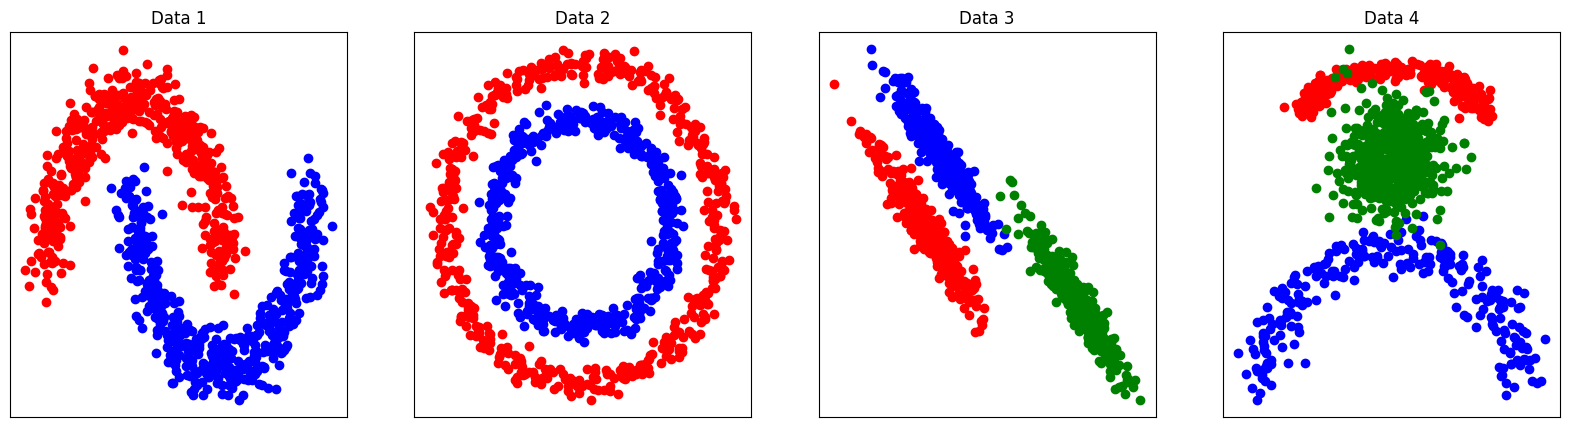

In [ ]:
data1 = moons()
data2 = circles()
data3 = streched_gaussians()
data4 = combined_structure()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels) in enumerate([data1, data2, data3, data4]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c='r')
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c='b')
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c='g')
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()


In [ ]:
LAM1 = LAMINAR.LAMINAR(data1[0], drop_freq=9999, epochs=1500, device=device)

Iteration 0 | Train Loss: 1841.64453125 | Validation Loss: 1841.231689453125
Iteration 99 | Train Loss: 273.8434143066406 | Validation Loss: 270.1252136230469
Iteration 199 | Train Loss: 261.1472473144531 | Validation Loss: 260.605712890625
Iteration 299 | Train Loss: 232.8079376220703 | Validation Loss: 238.91485595703125
Iteration 399 | Train Loss: 224.05572509765625 | Validation Loss: 231.26919555664062
Iteration 499 | Train Loss: 220.67494201660156 | Validation Loss: 228.35345458984375
Iteration 599 | Train Loss: 217.73329162597656 | Validation Loss: 224.43023681640625
Iteration 699 | Train Loss: 215.47726440429688 | Validation Loss: 224.18807983398438
Iteration 799 | Train Loss: 213.96507263183594 | Validation Loss: 223.30929565429688
Iteration 899 | Train Loss: 210.6165771484375 | Validation Loss: 222.03384399414062
Iteration 999 | Train Loss: 211.50225830078125 | Validation Loss: 222.28871154785156
Iteration 1099 | Train Loss: 205.78233337402344 | Validation Loss: 214.0464019775

In [ ]:
LAM2 = LAMINAR.LAMINAR(data2[0], drop_freq=9999, epochs=1500, device=device)

Iteration 0 | Train Loss: 1940.236328125 | Validation Loss: 1940.024658203125
Iteration 99 | Train Loss: 284.9114990234375 | Validation Loss: 281.305908203125
Iteration 199 | Train Loss: 283.6894226074219 | Validation Loss: 280.48974609375
Iteration 299 | Train Loss: 271.7460021972656 | Validation Loss: 275.79376220703125
Iteration 399 | Train Loss: 243.34559631347656 | Validation Loss: 244.8717803955078
Iteration 499 | Train Loss: 237.9412384033203 | Validation Loss: 242.041748046875
Iteration 599 | Train Loss: 235.33950805664062 | Validation Loss: 237.8474884033203
Iteration 699 | Train Loss: 234.7253875732422 | Validation Loss: 237.35621643066406
Iteration 799 | Train Loss: 231.61013793945312 | Validation Loss: 239.02694702148438
Iteration 899 | Train Loss: 230.64120483398438 | Validation Loss: 239.61270141601562
Iteration 999 | Train Loss: 228.85838317871094 | Validation Loss: 237.8346405029297
Iteration 1099 | Train Loss: 227.7015380859375 | Validation Loss: 237.09445190429688
Ite

In [ ]:
LAM3 = LAMINAR.LAMINAR(data3[0], drop_freq=9999, epochs=1500, device=device)

Iteration 0 | Train Loss: 1822.8861083984375 | Validation Loss: 1821.838623046875
Iteration 99 | Train Loss: 174.30628967285156 | Validation Loss: 186.6830291748047
Iteration 199 | Train Loss: 166.61058044433594 | Validation Loss: 175.6260223388672
Iteration 299 | Train Loss: 136.53945922851562 | Validation Loss: 143.7825927734375
Iteration 399 | Train Loss: 124.17720794677734 | Validation Loss: 136.7145233154297
Iteration 499 | Train Loss: 124.6446533203125 | Validation Loss: 135.4047393798828
Iteration 599 | Train Loss: 123.51130676269531 | Validation Loss: 132.06777954101562
Iteration 699 | Train Loss: 120.35707092285156 | Validation Loss: 131.69546508789062
Iteration 799 | Train Loss: 118.70525360107422 | Validation Loss: 131.27024841308594
Iteration 899 | Train Loss: 340.38897705078125 | Validation Loss: 362.3951110839844
Iteration 999 | Train Loss: 186.5838165283203 | Validation Loss: 196.8480682373047
Iteration 1099 | Train Loss: 151.91131591796875 | Validation Loss: 164.7543792

: 

In [ ]:
LAM4 = LAMINAR.LAMINAR(data4[0], drop_freq=9999, epochs=1500, device=device)

Iteration 0 | Train Loss: 1670.940185546875 | Validation Loss: 1665.92919921875
Iteration 99 | Train Loss: 266.3326416015625 | Validation Loss: 219.74908447265625
Iteration 199 | Train Loss: 235.44969177246094 | Validation Loss: 186.2949981689453
Iteration 299 | Train Loss: 241.959716796875 | Validation Loss: 193.2520751953125
Iteration 399 | Train Loss: 208.46505737304688 | Validation Loss: 199.72975158691406
Iteration 499 | Train Loss: 204.5000457763672 | Validation Loss: 193.4539337158203
Iteration 599 | Train Loss: 199.36976623535156 | Validation Loss: 195.00555419921875
Iteration 699 | Train Loss: 196.45501708984375 | Validation Loss: 196.93118286132812
Early stopping at iteration 699


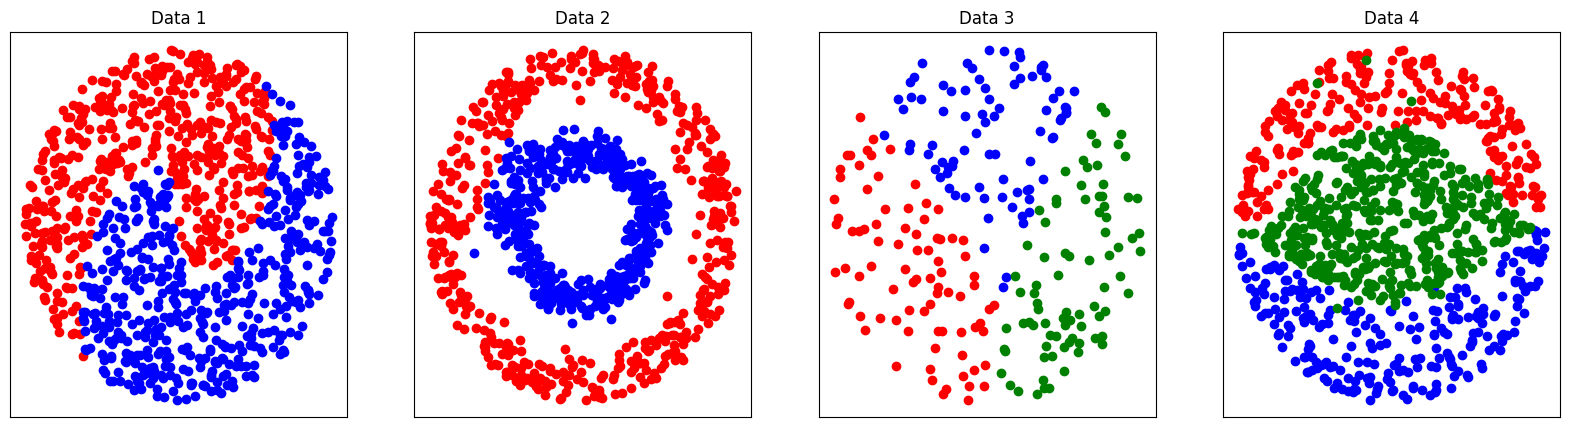

In [ ]:
data1_pushed = LAM1.X_pushed
data2_pushed = LAM2.X_pushed
data3_pushed = LAM3.X_pushed
data4_pushed = LAM4.X_pushed

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data_pushed, data in zip([0, 1, 2, 3], [data1_pushed, data2_pushed, data3_pushed, data4_pushed], [data1, data2, data3, data4]):
    axs[i].scatter(data_pushed[data[1] == 0, 0], data_pushed[data[1] == 0, 1], c='r')
    axs[i].scatter(data_pushed[data[1] == 1, 0], data_pushed[data[1] == 1, 1], c='b')
    axs[i].scatter(data_pushed[data[1] == 2, 0], data_pushed[data[1] == 2, 1], c='g')
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [ ]:
def k_medoids(X, k, max_iter=100):
    """
    K-Medoids clustering algorithm
    :param X: numpy array of shape (n_samples, n_features)
    :param k: Number of clusters
    :param max_iter: Maximum number of iterations
    :return: (medoids, labels)
    """
    n_samples = X.shape[0]
    
    # Randomly initialize k medoids
    medoid_indices = np.random.choice(n_samples, k, replace=False)
    medoids = X[medoid_indices]
    
    for _ in range(max_iter):
        # Compute distance matrix
        distances = pairwise_distances(X, medoids, metric='manhattan')
        
        # Assign labels based on closest medoid
        labels = np.argmin(distances, axis=1)
        
        # Update medoids
        new_medoids = np.copy(medoids)
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            
            # Compute cost for each cluster point as new medoid
            costs = np.sum(pairwise_distances(cluster_points, cluster_points, metric='manhattan'), axis=1)
            new_medoids[i] = cluster_points[np.argmin(costs)]
        
        # Check for convergence
        if np.all(new_medoids == medoids):
            break
        medoids = new_medoids
    
    return medoids, labels


def k_medoids_LAM(data, k, LAM, max_iter=1000):
    # initialize medoids
    medoids = data[torch.randperm(data.size(0))[:k]]
    n = data.shape[0]
    d = data.shape[1]
    for i in range(max_iter):
        # calculate distances
        idx, dists = LAM.query(medoids)
        dists = dists[idx < n].reshape(d, n)

        idx, sort_idx = torch.sort(idx, dim=1)
        for _ in range(k):
            dists[_] = dists[_, sort_idx[_]]

        # assign medoids
        _, assignments = dists.min(dim=0)
        new_medoids = torch.clone(medoids)
        # update medoids
        for j in range(k):
            
            # get indices of all points in the cluster j
            cluster_points = idx[j, assignments == j]

            if len(cluster_points) == 0:
                continue

            # get distance matrix of LAM
            distance_matrix = LAM.dist_matrix

            # only take rows and columns where cluster_points is True
            distance_matrix = distance_matrix[cluster_points][:, cluster_points]

            distance_matrix = torch.tensor(distance_matrix, dtype=torch.float32)
            # sum over all columns
            sum = torch.sum(distance_matrix, dim=1)

            #print(sum)
            # minimum of the sum is the new medoid centre
            new_medoids[j] = data[cluster_points][sum.argmin()]

            print('Lowest value in iteration', i, 'is', sum.min(), 'at', new_medoids[j])
            medoids = new_medoids
    return medoids, assignments

In [ ]:
# do clustering for all datasets with euclidean metric

medoids1, labels1 = k_medoids(data1[0], 2)
medoids2, labels2 = k_medoids(data2[0], 2)
medoids3, labels3 = k_medoids(data3[0], 3)
medoids4, labels4 = k_medoids(data4[0], 3)

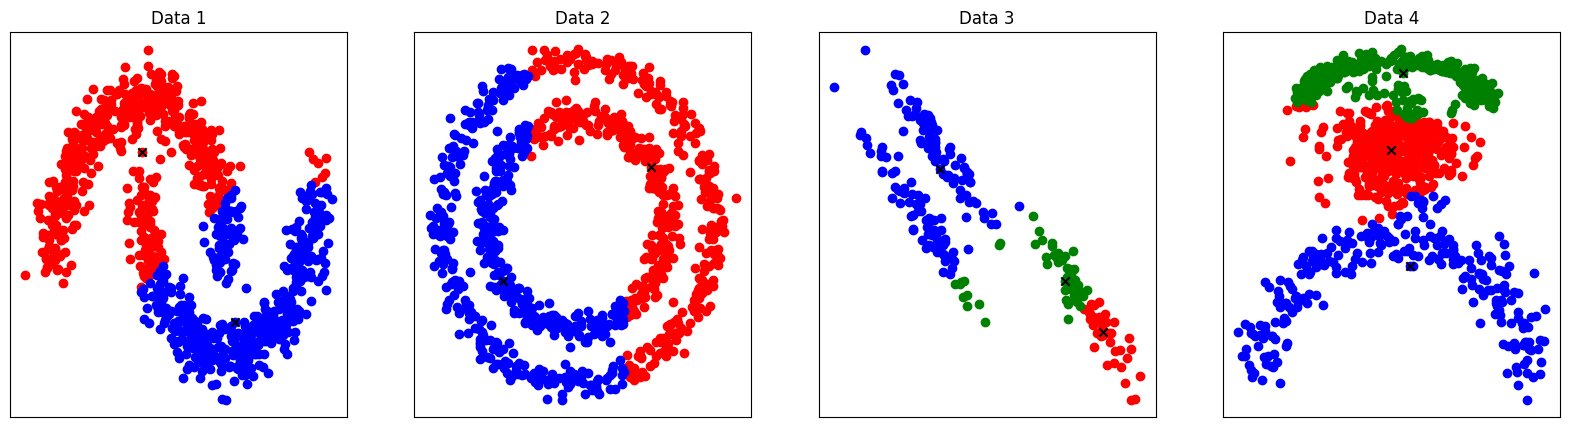

In [ ]:
# plot clustering with euclidean
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1, medoids1), (data2[0], labels2, medoids2), (data3[0], labels3, medoids3), (data4[0], labels4, medoids4)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c='r')
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c='b')
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c='g')
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x')
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [ ]:
# same with LAM

medoids1, labels1 = k_medoids_LAM(data1[0], 2, LAM1)
medoids2, labels2 = k_medoids_LAM(data2[0], 2, LAM2)
medoids3, labels3 = k_medoids_LAM(data3[0], 3, LAM3)
medoids4, labels4 = k_medoids_LAM(data4[0], 3, LAM4)

H:\Uni\Master\Thesis\NFLAM\NFLAM\LAMINAR\LAMINAR\LAMINAR.py:189: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dists = torch.tensor(dist_matrix[idx_points]) # shape (m, n)


Lowest value in iteration 0 is tensor(130.3687) at tensor([-0.6202,  1.3700])
Lowest value in iteration 0 is tensor(76.8062) at tensor([ 0.6260, -1.3406])
Lowest value in iteration 1 is tensor(120.9450) at tensor([-0.6202,  1.3700])
Lowest value in iteration 1 is tensor(85.3493) at tensor([ 0.6558, -1.3572])
Lowest value in iteration 2 is tensor(120.9450) at tensor([-0.6202,  1.3700])
Lowest value in iteration 2 is tensor(85.3493) at tensor([ 0.6558, -1.3572])
Lowest value in iteration 3 is tensor(120.9450) at tensor([-0.6202,  1.3700])
Lowest value in iteration 3 is tensor(85.3493) at tensor([ 0.6558, -1.3572])
Lowest value in iteration 4 is tensor(120.9450) at tensor([-0.6202,  1.3700])
Lowest value in iteration 4 is tensor(85.3493) at tensor([ 0.6558, -1.3572])
Lowest value in iteration 5 is tensor(120.9450) at tensor([-0.6202,  1.3700])
Lowest value in iteration 5 is tensor(85.3493) at tensor([ 0.6558, -1.3572])
Lowest value in iteration 6 is tensor(120.9450) at tensor([-0.6202,  1

RuntimeError: shape '[2, 250]' is invalid for input of size 750

In [ ]:
# plot clustering with LAM
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1, medoids1), (data2[0], labels2, medoids2), (data3[0], labels3, medoids3), (data4[0], labels4, medoids4)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c='r')
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c='b')
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c='g')
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x')
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])